## Imports

In [11]:
import sys
import os

from typing import Any, Annotated, List, Literal
from operator import add
import uuid
import json

from openai import OpenAI
from pydantic import BaseModel, Field, field_validator
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from tools.tools import (
    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    get_formatted_cm_context,
    get_sensor_catalog_tool, get_threshold_events_tool,
    get_sensor_timeline_tool, get_sensor_readings_tool,
    get_sensor_anomaly_summary,
    get_remaining_life_tool,
    query_known_issues_graph,
    get_intervention_detail,
    get_fleet_impact_for_symptom,
)

from utils.prompt_management import prompt_template_config


GENERATION_MODEL = "gpt-4o-mini"


## States

In [ ]:
class Reference(BaseModel):
    source_id: str
    source_type: Literal['PROC_REF', 'GRAPH', 'INT', 'USER'] = 'GRAPH'

class Hypothesis(BaseModel):
    source_id: str
    statement: str
    confidence: float
    status: Literal['ACTIVE', 'CONFIRMED', 'REJECTED', 'LIKELY']
    source: list[Reference] = []
    explanation: str = ""

def merge_hypotheses(left: dict, right: dict) -> dict:
    """Right-wins merge by id. Tools always emit full Hypothesis objects."""
    return {**left, **right}

class AgentState(BaseModel):
    machine_id: str = ""
    symptom: str = ""
    messages: Annotated[List[Any], merge_hypotheses] = Field(default_factory=list)
    hypotheses: list[Hypothesis] = Field(default_factory=list)
    answer: str = ""
    final_answer: bool = False
    confirmed_root_cause: str = ""
    
class FinalRCAResponse(BaseModel):
    answer: str = Field(description="Final answer or follow-up question to the user.")
    hypotheses: list[Hypothesis] = Field(default_factory=list, description="Current evidence ledger.")

class CaseSummary(BaseModel):
    machine_id: str = ""
    symptom: str = Field(description = "One-sentence summary extracted from the investigation.")
    root_cause: str = Field(description="One-sentence root cause extracted from the investigation.")
    actions: list[str] = Field(description="List of concrete actions to resolve the issue, extracted from the conversation.")

CONFIRMED = 0.9
LIKELY = 0.7
ACTIVE = 0.25
REJECTED = 0.20


## Tools

In [ ]:
ALL_TOOLS = [
    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    query_known_issues_graph,
    get_intervention_detail,
    get_fleet_impact_for_symptom,
]

print(f"Defined {len(ALL_TOOLS)} tools: {[t.name for t in ALL_TOOLS]}")

_llm = ChatOpenAI(model=GENERATION_MODEL)
_llm_with_tools = _llm.bind_tools(ALL_TOOLS + [FinalRCAResponse], tool_choice="auto", parallel_tool_calls=True)


Defined 17 tools: ['get_current_date', 'calculate_date_window', 'check_machine_exists', 'list_available_machines', 'get_formatted_procedure_context', 'get_recent_formatted_cm_context', 'get_long_formatted_cm_context', 'get_formatted_cm_context', 'get_sensor_catalog_tool', 'get_threshold_events_tool', 'get_sensor_timeline_tool', 'get_sensor_readings_tool', 'get_sensor_anomaly_summary', 'get_remaining_life_tool', 'query_known_issues_graph', 'get_intervention_detail', 'get_fleet_impact_for_symptom']


In [ ]:
def format_ledger(hypotheses: list[Hypothesis]) -> str:
    if not hypotheses:
        return "(No hypotheses yet)"
    lines = []
    for h in sorted(hypotheses, key=lambda x: x.confidence, reverse=True):
        emoji = {"CONFIRMED": "✓", "REJECTED": "✗", "LIKELY": "◎", "ACTIVE": "○"}.get(h.status, "·")
        sources = ", ".join(s.source_id for s in h.source) or "no sources yet"
        lines.append(f"{emoji} {h.source_id} [{h.status}] {h.statement} — conf={h.confidence:.2f}")
        if h.explanation:
            lines.append(f"  Explanation: {h.explanation}")
        lines.append(f"  Sources: {sources}")
    return "\n".join(lines)

import uuid

def display_hypothesis_ledger(hypotheses):
    if not hypotheses:
        return
    print("\n## Evidence Ledger\n---")
    print(format_ledger(hypotheses))
    print("---\n")


## Agent Node

In [ ]:
import re

# CONFIRMED requires explicit user confirmation. Without a USER source,
# any hypothesis the model marks as CONFIRMED gets capped at LIKELY (0.79).
_USER_CONFIRMED_CEILING = 0.79


def _finalize_ledger(hypotheses: list[Hypothesis]) -> list[Hypothesis]:
    """Enforce sourcing rules. CONFIRMED requires a USER source; otherwise cap at LIKELY."""
    finalized = []
    for h in hypotheses:
        has_user_source = any(
            (s.source_type == "USER") or (s.source_id.upper() == "USER")
            for s in h.source
        )
        if h.status == "CONFIRMED" and not has_user_source:
            h = h.model_copy(update={
                "status": "LIKELY",
                "confidence": min(h.confidence, _USER_CONFIRMED_CEILING),
            })
        finalized.append(h)
    return finalized


# [AWAITING USER FEEDBACK] is a control signal — strip it from the user-facing answer.
_AWAITING_RE = re.compile(r"\s*\[AWAITING USER FEEDBACK\]\s*", re.IGNORECASE)


def _strip_awaiting_marker(text: str) -> tuple[str, bool]:
    is_awaiting = bool(_AWAITING_RE.search(text))
    clean = _AWAITING_RE.sub("", text).rstrip()
    return clean, is_awaiting


def agent_node(state: AgentState) -> dict:
    SYSTEM_PROMPT = prompt_template_config("prompts/rca_react_system_prompt.yml", name="system_prompt")
    ledger_context = format_ledger(state.hypotheses)

    system_msg = SystemMessage(content=SYSTEM_PROMPT)
    ledger_msg = SystemMessage(content=f"## Current Evidence Ledger\n\n{ledger_context}")

    response = _llm_with_tools.invoke([system_msg, ledger_msg, *state.messages])

    # LLM called FinalRCAResponse — happy path
    final_call = next(
        (tc for tc in response.tool_calls if tc["name"] == "FinalRCAResponse"),
        None
    )
    if final_call:
        parsed = FinalRCAResponse(**final_call["args"])
        clean_answer, _ = _strip_awaiting_marker(parsed.answer)
        finalized = _finalize_ledger(parsed.hypotheses)
        ack = ToolMessage(content="ok", tool_call_id=final_call["id"])
        return {
            "messages": [response, ack],
            "hypotheses": finalized,
            "answer": clean_answer,
            "final_answer": True,
        }

    # LLM called real tools — let tools node run
    if response.tool_calls:
        return {"messages": [response], "final_answer": False}

    # Plain text response — recover structured output from prose.
    tool_outputs = [m.content for m in state.messages if isinstance(m, ToolMessage)]
    extracted = _extract_final_response_from_prose(response.content, state.hypotheses, tool_outputs)
    clean_answer, _ = _strip_awaiting_marker(extracted.answer)
    finalized = _finalize_ledger(extracted.hypotheses)
    return {
        "messages": [response],
        "answer": clean_answer,
        "hypotheses": finalized,
        "final_answer": True,
    }


In [17]:
# --- Confirmation gate ---
# Only prompt "save this case?" when the investigation has converged
# (dominant hypothesis) OR the user explicitly asked to save.

SAVE_INTENT_PHRASES = (
    "save it", "save this", "save the case", "that's it", "thats it",
    "go ahead", "confirm it", "you can save", "log it", "close the case",
)


def _has_dominant_hypothesis(hypotheses: list[Hypothesis]) -> bool:
    if not hypotheses:
        return False
    ranked = sorted(hypotheses, key=lambda h: h.confidence, reverse=True)
    top = ranked[0].confidence
    second = ranked[1].confidence if len(ranked) > 1 else 0.0
    return top >= 0.80 and (top - second) >= 0.20


def _user_signaled_save(state: AgentState) -> bool:
    last_human = next(
        (m for m in reversed(state.messages) if isinstance(m, HumanMessage)),
        None,
    )
    if not last_human:
        return False
    text = last_human.content.lower()
    return any(phrase in text for phrase in SAVE_INTENT_PHRASES)


def route_after_agent(state: AgentState) -> str:
    if state.diagnosis_confirmed:
        return "__end__"
    if state.final_answer:
        if _has_dominant_hypothesis(state.hypotheses) or _user_signaled_save(state):
            return "confirm_diagnosis"
        return "__end__"
    last_msg = state.messages[-1]
    if isinstance(last_msg, AIMessage) and getattr(last_msg, 'tool_calls', None):
        return "tools"
    return "__end__"

In [18]:
def confirmation_node(state: AgentState) -> dict:
    top = sorted(state.hypotheses, key=lambda x: x.confidence, reverse=True)[0] if state.hypotheses else None
    if not top:
        return {"answer": "No diagnosis available to confirm."}

    prompt = (
        f"Based on the investigation, the most likely root cause is:\n\n"
        f"**{top.statement}** (confidence: {top.confidence:.0%})\n\n"
        f"Reply **yes** to save this case, or **no** to keep investigating."
    )
    return {"answer": prompt, "diagnosis_offered": True}


def route_after_confirmation(state: AgentState) -> str:
    if state.diagnosis_confirmed:
        return "__end__"
    last_msg = state.messages[-1]
    if isinstance(last_msg, HumanMessage):
        content = last_msg.content.lower()
        if "yes" in content:
            return "closure"
        if "no" in content:
            return "agent"
    return "__end__"


def save_case(machine: str, root_cause: str, actions: list[str]) -> dict:
    case_id = f"CASE-{uuid.uuid4().hex[:8].upper()}"
    print(f"[MOCK DB] Saved {case_id}: machine={machine}, cause={root_cause[:60]}")
    return {"case_id": case_id}


def closure_node(state: AgentState) -> dict:
    top = sorted(state.hypotheses, key=lambda x: x.confidence, reverse=True)[0] if state.hypotheses else None
    if not top:
        return {"final_answer": True, "answer": "Nothing to save."}

    # Extract root cause + actions from the conversation history
    history = "\n".join(
        f"{type(m).__name__}: {m.content}"
        for m in state.messages
        if isinstance(m, (HumanMessage, AIMessage)) and m.content
    )
    extraction_prompt = (
        f"Based on this RCA investigation conversation, extract:\n"
        f"1. The confirmed root cause (one sentence)\n"
        f"2. The concrete actions the technician should take to resolve it\n\n"
        f"Conversation:\n{history}"
    )
    summary: CaseSummary = _llm.with_structured_output(CaseSummary).invoke(
        [HumanMessage(content=extraction_prompt)]
    )

    result = save_case(
        machine=state.machine_id or "UNKNOWN",
        root_cause=summary.root_cause,
        actions=summary.actions,
    )

    actions_text = "\n".join(f"- {a}" for a in summary.actions)
    answer = (
        f"✓ Case saved (ID: {result['case_id']})\n\n"
        f"**Machine:** {state.machine_id or 'UNKNOWN'}\n"
        f"**Root Cause:** {summary.root_cause}\n\n"
        f"**Actions:**\n{actions_text}\n\n"
        f"Thank you. Investigation complete."
    )
    return {"diagnosis_confirmed": True, "confirmed_root_cause": summary.root_cause, "final_answer": True, "answer": answer}


In [ ]:
def tools_node(state: AgentState) -> dict:
    tool_node = ToolNode(ALL_TOOLS)
    return tool_node.invoke(state)


In [ ]:

workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.add_node("confirm_diagnosis", confirmation_node)
workflow.add_node("closure", closure_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", route_after_agent, {"tools": "tools", "confirm_diagnosis": "confirm_diagnosis", "__end__": END})
workflow.add_edge("tools", "agent")
workflow.add_conditional_edges("confirm_diagnosis", route_after_confirmation, {"closure": "closure", "agent": "agent", "__end__": END})
workflow.add_edge("closure", END)

graph = workflow.compile(checkpointer=MemorySaver())


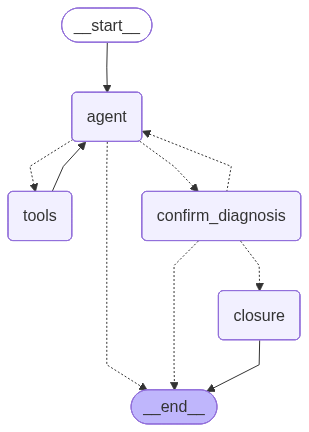

In [20]:

from utils.utils import display_graph
display_graph(graph)

In [21]:
result = graph.invoke(
    {"messages": [HumanMessage(content="The HX-200 hydraulic press is showing high oil temperature warnings. Check the current sensor readings, the remaining life of its components, and look up the troubleshooting procedure for overtemperature faults.")]},
    config={"configurable": {"thread_id": "hx200-test"}}
)

print(result["answer"])
display_hypothesis_ledger(result.get("hypotheses", []))

I've gathered the data for the HX-200 hydraulic press. Here's what I found:

1. **Current Sensor Reading**: The oil temperature is at **48°C**, which is within the nominal range (35°C - 65°C), indicating that currently, it’s not above the threshold.

2. **Remaining Life of Components**:
   - The **Pump Bearing Set**, **Pressure Sensor Outlet**, and other components are noted as overdue for replacement, while crucial components like the **Hydraulic Pump** and **Accumulator Bladder** are at the end of their life with very limited remaining hours.
  
3. **Troubleshooting Procedure for Overtemperature Faults**: The procedure documentation related to overtemperature faults was retrieved but isn't displayed due to the nature of the investigation — we can review that if needed.

4. **Threshold Events**: No threshold breaches related to the oil temperature have been recorded between October 17 and October 24, indicating no alarm conditions were met during that timeframe.

### What next?
Given 

In [22]:
def multi_turn_rca_chat():
    print("✓ Interactive RCA Agent — type 'exit' to quit.\n")

    thread_id = f"rca-{uuid.uuid4().hex[:12]}"
    config = {"configurable": {"thread_id": thread_id}}

    while True:
        user_input = input("You: ").strip()
        if user_input.lower() == "exit":
            print("\nSession ended.")
            break
        if not user_input:
            continue

        result = graph.invoke(
            {"messages": [HumanMessage(content=user_input)]},
            config=config,
        )

        print(f"\nAgent:\n{result['answer']}\n")
        display_hypothesis_ledger(result.get("hypotheses", []))

        if result.get("diagnosis_offered") and not result.get("diagnosis_confirmed"):
            confirm_input = input("You: ").strip()
            # Inject the user reply into the checkpoint as if confirm_diagnosis just ran,
            # then resume — this triggers route_after_confirmation correctly.
            graph.update_state(
                config,
                {"messages": [HumanMessage(content=confirm_input)]},
                as_node="confirm_diagnosis",
            )
            result = graph.invoke(None, config=config)
            print(f"\nAgent:\n{result['answer']}\n")

        if result.get("diagnosis_confirmed"):
            print("\nSession complete. Case saved.")
            break


multi_turn_rca_chat()


✓ Interactive RCA Agent — type 'exit' to quit.


Agent:
I've gathered some important information regarding the high oil temperature issue with the HX-200 machine. Here's what I found:

### Procedures
1. **Diagnosis Steps for High Oil Temperature**:
   - Check the temperature reading on TS-101 and monitor for trends.
   - Ensure the cooler fan (HE-501) is operating properly and clear any debris from the fan inlet.
   - Inspect the cooler fins for contamination and clean if necessary.
   - Verify the ambient shop temperature is below 40°C; if it's higher, consider additional cooling.
   - Ensure the cycle time is within specifications to allow adequate cooling.
   - If the temperature exceeds 75°C, stop the machine and analyze the oil sample.
   - Check the water flow for water-cooled variants.

   *Source: [HX-200 Troubleshooting Procedures]*

### Known Issues
1. **Root causes for High Oil Temperature**:
   - Low oil level
   - Cooler fouling
   - Cooling fan motor failure
   - Ambient 